## Modeling with K-Nearest Neighbors, Red Wine Quality Prediction (Classification Problem)

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

###### importing the dataset and observing a sample


In [37]:
redwine_df = pd.read_csv('../winequality-red-clean.csv', sep=',')
redwine_df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1437,-1.282442,1.037213,-0.602917,3.134395,-0.262062,-0.224366,-0.566664,-0.289750,1.585042,-0.326998,1.453569,6
866,0.114019,-0.319428,0.024679,-0.564985,-1.107488,0.312433,-0.192566,-0.895144,-1.107182,1.600406,0.669459,6
456,1.449764,-0.732319,1.122973,-0.333774,2.039377,-0.009646,0.181533,0.746407,-2.028206,1.292021,-0.702735,6
415,0.235450,1.745026,-1.282813,-1.374224,-0.543870,2.244910,0.147524,-0.883502,-0.823790,-0.481190,-0.604721,5
502,-0.432422,-1.381147,1.175272,0.359860,0.489428,1.063952,0.555631,0.222508,-0.044462,-0.249901,-0.310680,6


##### checking the data types of the columns

In [38]:
redwine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1458 non-null   float64
 1   volatile acidity      1458 non-null   float64
 2   citric acid           1458 non-null   float64
 3   residual sugar        1458 non-null   float64
 4   chlorides             1458 non-null   float64
 5   free sulfur dioxide   1458 non-null   float64
 6   total sulfur dioxide  1458 non-null   float64
 7   density               1458 non-null   float64
 8   pH                    1458 non-null   float64
 9   sulphates             1458 non-null   float64
 10  alcohol               1458 non-null   float64
 11  quality               1458 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 136.8 KB


##### Simple Descriptive Analysis and checking the distribution of the data

In [39]:
redwine_df.describe().T.style.background_gradient(axis=0)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1458.000000,-0.000000,1.000343,-2.011030,-0.736001,-0.250275,0.539029,3.149804
volatile acidity,1458.000000,0.000000,1.000343,-2.383882,-0.791303,-0.024506,0.653815,3.042683
citric acid,1458.000000,-0.000000,1.000343,-1.387413,-0.916715,-0.079920,0.809175,2.744263
residual sugar,1458.000000,0.000000,1.000343,-1.374224,-0.564985,-0.218168,0.244255,4.984085
chlorides,1458.000000,0.000000,1.000343,-2.046850,-0.543870,-0.121157,0.348524,6.783157
free sulfur dioxide,1458.000000,-0.000000,1.000343,-1.512683,-0.868525,-0.224366,0.634513,3.425867
total sulfur dioxide,1458.000000,-0.000000,1.000343,-1.280852,-0.770718,-0.260584,0.487613,3.446391
density,1458.000000,-0.000000,1.000343,-3.037311,-0.650658,-0.010337,0.629985,3.191270
pH,1458.000000,0.000000,1.000343,-3.090926,-0.682094,-0.009038,0.593170,3.072849
sulphates,1458.000000,0.000000,1.000343,-2.408593,-0.712478,-0.172805,0.598156,3.990386


### the scater plot of the data below, describes the relationship between the density and alcohol content of the red wine.
the data shows that the density of the red wine is inversely proportional to the alcohol content. The higher the alcohol content, the lower the density of the red wine.

<Axes: xlabel='density', ylabel='alcohol'>

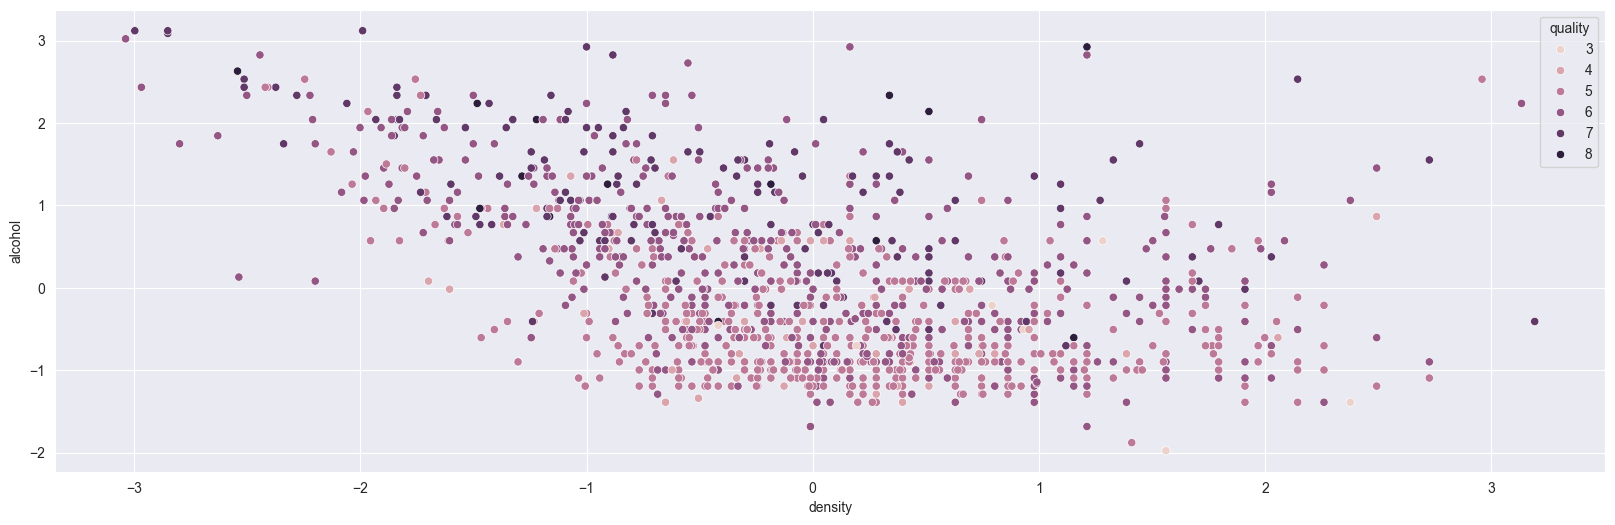

In [40]:
plt.figure(figsize=(20, 6))
sns.scatterplot(x='density', y='alcohol', data= redwine_df, hue='quality')

##### checking the distribution of the data for each target category

In [41]:
redwine_df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

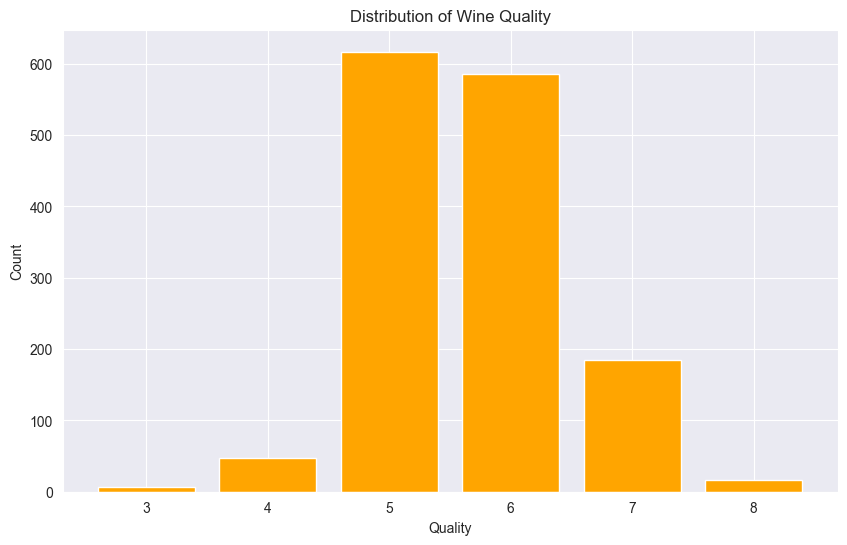

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

quality_counts = redwine_df['quality'].value_counts().sort_index()

quality_df = pd.DataFrame({'quality': quality_counts.index, 'count': quality_counts.values})

plt.figure(figsize=(10, 6))
plt.bar(quality_df['quality'], quality_df['count'], color='orange')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.title('Distribution of Wine Quality')
plt.xticks(quality_df['quality'])  # Ensure the x-axis labels match the quality values
plt.show()

#Interesting Correlations:

Fixed acidity and pH have a strong negative correlation (-0.68), meaning that as fixed acidity increases, pH decreases.

Alcohol and quality have a moderately positive correlation (0.48), suggesting that higher alcohol content is associated with better quality.

Free sulfur dioxide and total sulfur dioxide have a high positive correlation (0.67), which makes sense since they are related chemically.

Low or Negligible Correlations: Some variables, like chlorides and citric acid, show almost no correlation (0.056), meaning they don’t have a significant linear relationship.

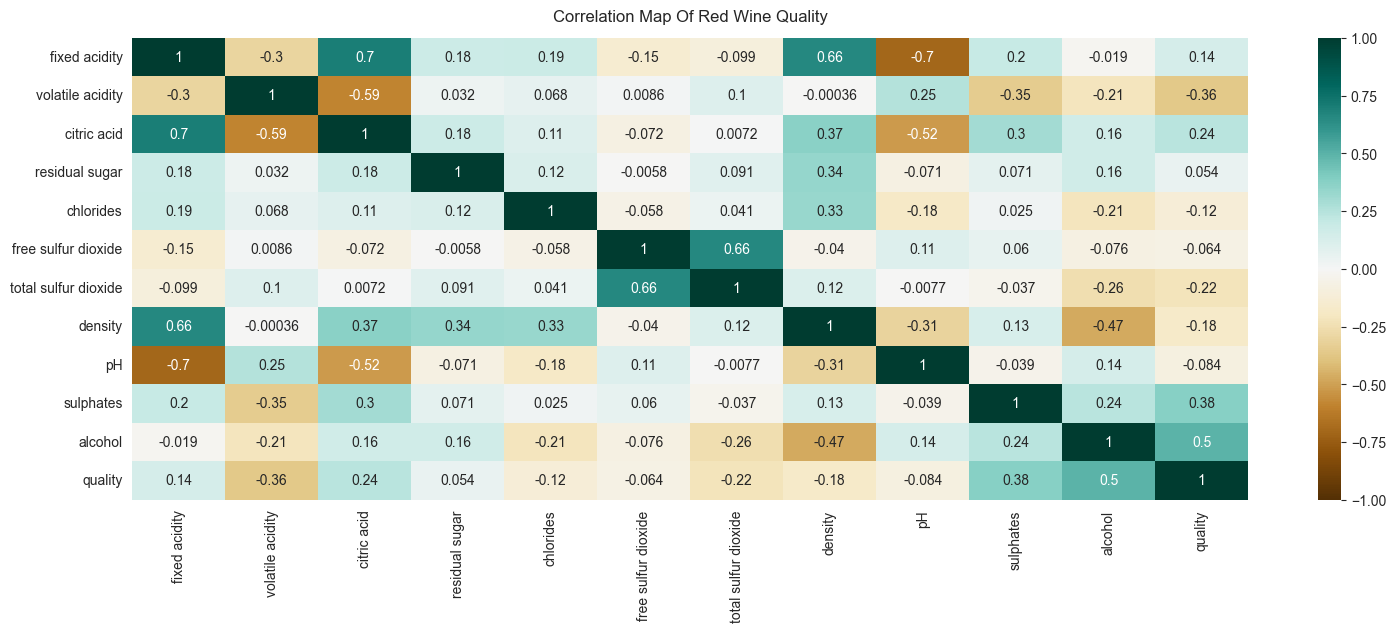

In [43]:
plt.figure(figsize=(18, 6))
sns.heatmap(redwine_df.corr(), vmin=-1, vmax=1, annot=True, cmap='BrBG')
plt.title('Correlation Map Of Red Wine Quality', fontdict={'fontsize':12}, pad=12);

##### splitting the data to test and train samples and use them to train the model.

In [44]:
X = redwine_df.drop(['quality'], axis = 1) # independent variables
y = redwine_df['quality'] # dependent variable

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# selected features are selected based on the top features which have the highest correlation with the target variable.heatmap
selected_features = ['volatile acidity', 'citric acid', 'total sulfur dioxide', 'sulphates','alcohol', 'density']

In [46]:

X = redwine_df[selected_features]
y = redwine_df['quality']
# using standard scaler to scale the data and normalize it
standard_scaler = StandardScaler()
X = standard_scaler.fit_transform(X)
# splitting the data to test and train samples using 80% of the data for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


In [47]:
X

array([[ 1.03721328, -1.38741253, -0.2435791 , -0.63538217, -0.99677646,
         0.62998477],
       [ 2.0989326 , -1.38741253,  0.79369348,  0.2897715 , -0.60472114,
         0.04787439],
       [ 1.39111972, -1.17821377,  0.3515773 ,  0.05848308, -0.60472114,
         0.16429646],
       ...,
       [-0.08349045, -0.70751654, -0.12454782,  0.82944447,  0.57144484,
        -0.56916262],
       [ 0.71279904, -0.75981623,  0.01148793,  0.52105991, -0.21266581,
        -0.72633242],
       [-1.26317858,  1.07067297, -0.05652994,  0.13557922,  0.57144484,
        -0.71469021]])

## *Find Best K-Score*

A large K value has benefits which include reducing the variance due to the noisy data, the side effect being developing a bias due to which the learner tends to ignore the smaller patterns which may have useful insights. The data indicates underfitting.

K = 3: Training Accuracy = 0.8105, Testing Accuracy = 0.5651, Overfitting Score = 0.2454
K = 4: Training Accuracy = 0.7410, Testing Accuracy = 0.5925, Overfitting Score = 0.1485
K = 5: Training Accuracy = 0.7264, Testing Accuracy = 0.5719, Overfitting Score = 0.1545
K = 6: Training Accuracy = 0.6981, Testing Accuracy = 0.5856, Overfitting Score = 0.1125
K = 7: Training Accuracy = 0.6947, Testing Accuracy = 0.5993, Overfitting Score = 0.0954
K = 8: Training Accuracy = 0.6904, Testing Accuracy = 0.6164, Overfitting Score = 0.0740
K = 9: Training Accuracy = 0.6741, Testing Accuracy = 0.6062, Overfitting Score = 0.0679
K = 10: Training Accuracy = 0.6724, Testing Accuracy = 0.6027, Overfitting Score = 0.0696
K = 11: Training Accuracy = 0.6595, Testing Accuracy = 0.5925, Overfitting Score = 0.0671
K = 12: Training Accuracy = 0.6578, Testing Accuracy = 0.6096, Overfitting Score = 0.0482
K = 13: Training Accuracy = 0.6569, Testing Accuracy = 0.6062, Overfitting Score = 0.0508
K = 14: Training 

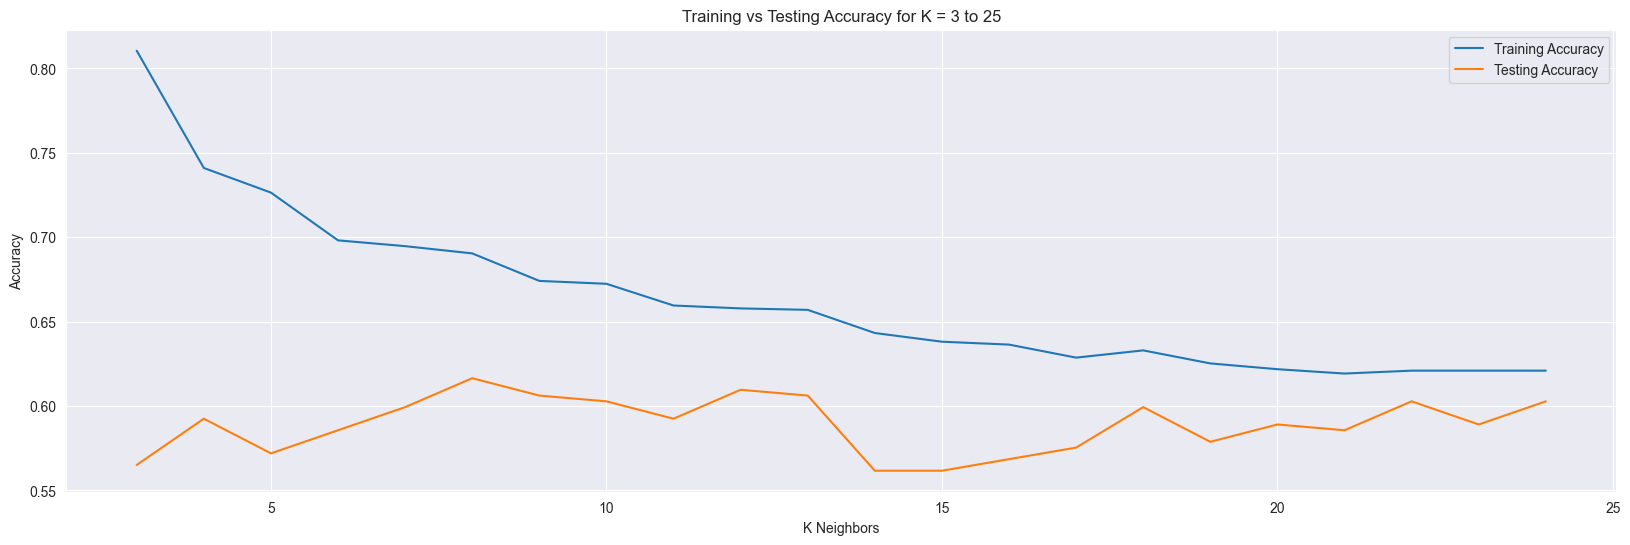

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline   
from sklearn.preprocessing import StandardScaler

# Function to find the best K and perform overfitting analysis
def find_best_k(X_train, y_train, X_test, y_test, k_range):
    training_accuracy = []
    testing_accuracy = []
    overfitting_scores = []  # To store the overfitting scores for each K
    best_k = 0
    best_score = 0
    
    k_values = np.arange(k_range[0], k_range[1], k_range[2])

    # Loop over the different K values
    for k in k_values:
        # Define the KNN model with current K value
        knn = KNeighborsClassifier(n_neighbors=k)
        # Create a pipeline with StandardScaler and KNN
        pipeline = Pipeline([('scaler', StandardScaler()), ('knn', knn)])
        
        # Train the model on the training data
        pipeline.fit(X_train, y_train)
        
        # Evaluate on training data
        train_accuracy = pipeline.score(X_train, y_train)
        training_accuracy.append(train_accuracy)
        
        # Evaluate on test data
        test_accuracy = pipeline.score(X_test, y_test)
        testing_accuracy.append(test_accuracy)
        
        # Calculate overfitting score
        overfitting_score = train_accuracy - test_accuracy
        overfitting_scores.append(overfitting_score)
        
        # Print the k value, corresponding accuracies, and overfitting score
        print(f"K = {k}: Training Accuracy = {train_accuracy:.4f}, Testing Accuracy = {test_accuracy:.4f}, Overfitting Score = {overfitting_score:.4f}")
        
        # Check if the test accuracy is the best
        if test_accuracy > best_score:
            best_k = k
            best_score = test_accuracy
    
    # Analysis for overfitting or underfitting
    for idx, k in enumerate(k_values):
        if overfitting_scores[idx] > 0.05:  # Threshold for overfitting
            print(f"At K={k}, the model might be overfitting (Overfitting Score: {overfitting_scores[idx]:.4f}).")
        elif overfitting_scores[idx] < -0.05:  # Significant negative score indicating possible underfitting
            print(f"At K={k}, the model might be underfitting (Overfitting Score: {overfitting_scores[idx]:.4f}).")
        else:
            print(f"At K={k}, no significant overfitting or underfitting detected (Overfitting Score: {overfitting_scores[idx]:.4f}).")
    
    return best_k, best_score, training_accuracy, testing_accuracy, k_values

# Find the best K for k_range (3, 25)
best_k, best_score, training_accuracy, testing_accuracy, k_values = find_best_k(X_train, y_train, X_test, y_test, k_range=(3, 25, 1))

# Print the best K and the best score
print(f"\nBest K for range 3-25: {best_k}")
print(f"Best Testing Accuracy for range 3-25: {best_score:.4f}")

# Plot for K range 3-25
plt.figure(figsize=(20, 6))
sns.lineplot(x=k_values, y=training_accuracy, label="Training Accuracy")
sns.lineplot(x=k_values, y=testing_accuracy, label="Testing Accuracy")
plt.title("Training vs Testing Accuracy for K = 3 to 25")
plt.xlabel("K Neighbors")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


# Modeling

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# Define the KNN model with K=8 and create a pipeline with StandardScaler
knn = KNeighborsClassifier(n_neighbors=8)
pipe_knn = Pipeline([('scaler', StandardScaler()), ('knn', knn)])

# Fit the model to the training data
pipe_knn.fit(X_train, y_train)

# Predict on the test set
y_pred = pipe_knn.predict(X_test)

# Calculate and print the accuracy and classification report
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=1))


Test Accuracy: 0.6164
Classification Report:
              precision    recall  f1-score   support

           3       1.00      0.00      0.00         2
           4       1.00      0.20      0.33         5
           5       0.61      0.70      0.65       116
           6       0.62      0.61      0.62       135
           7       0.60      0.50      0.55        30
           8       1.00      0.00      0.00         4

    accuracy                           0.62       292
   macro avg       0.81      0.34      0.36       292
weighted avg       0.63      0.62      0.61       292



# HyperParameter Tuning

In [50]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid, including leaf_size values
param_grid = {
    'knn__n_neighbors': [6, 8, 10, 12, 14, 16, 18, 20, 22, 24],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['manhattan', 'euclidean'],
    'knn__algorithm': ['ball_tree', 'kd_tree', 'brute']
}

# Perform GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(pipe_knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best parameters and score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")


Best parameters: {'knn__algorithm': 'ball_tree', 'knn__metric': 'manhattan', 'knn__n_neighbors': 18, 'knn__weights': 'distance'}
Best cross-validation score: 0.6852


C:\Program Files\Python312\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [51]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Define the KNN model with the best parameters from GridSearchCV and StandardScaler
knn_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        algorithm='ball_tree',
        metric='manhattan',
        n_neighbors=18,
        weights='distance'    ))
])

# Fit the model with the tuned hyperparameters on the training data
knn_tuned.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn_tuned.predict(X_test)

# Evaluate the tuned model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of tuned KNN model: {accuracy:.4f}")


Accuracy of tuned KNN model: 0.6815
